In [1]:
import pandas as pd
df = pd.read_excel('SQL_Sales_Dataset_200_Rows.xlsx')
print(df.head)

<bound method NDFrame.head of      order_id     customer_name order_date   category sub_category  \
0        1000       Caleb Davis 2025-01-31   Clothing        Jeans   
1        1001     Misty Herrera 2025-05-05   Clothing        Jeans   
2        1002         Rick Soto 2025-06-09   Clothing        Shoes   
3        1003         Sean Haas 2025-02-27  Furniture         Desk   
4        1004          Ann Hall 2025-06-01  Furniture      Cabinet   
..        ...               ...        ...        ...          ...   
195      1195      Dylan Baxter 2025-02-15   Clothing        Jeans   
196      1196  Brandon Callahan 2025-02-26    Grocery       Snacks   
197      1197    Angela Stanton 2025-06-16  Furniture      Cabinet   
198      1198   Marissa Aguilar 2025-06-02    Grocery         Milk   
199      1199   Timothy Wheeler 2025-01-29   Clothing        Shirt   

       product_name  quantity  unit_price  total_price region  
0         Jeans Try         2        1197         2394   West  
1

In [2]:
print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())


Dataset Shape:
(200, 10)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       200 non-null    int64         
 1   customer_name  200 non-null    str           
 2   order_date     200 non-null    datetime64[us]
 3   category       200 non-null    str           
 4   sub_category   200 non-null    str           
 5   product_name   200 non-null    str           
 6   quantity       200 non-null    int64         
 7   unit_price     200 non-null    int64         
 8   total_price    200 non-null    int64         
 9   region         200 non-null    str           
dtypes: datetime64[us](1), int64(4), str(5)
memory usage: 15.8 KB

Statistical Summary:


,order_id,order_date,quantity,unit_price,total_price
count,200.000000,200,200.000000,200.000000,200.000000
mean,1099.500000,2025-03-27 22:33:36,4.910000,2421.495000,12100.535000
min,1000.000000,2024-12-24 00:00:00,1.000000,79.000000,79.000000
25%,1049.750000,2025-02-14 00:00:00,2.000000,1120.000000,3060.000000
50%,1099.500000,2025-03-28 12:00:00,5.000000,2373.500000,8912.000000
75%,1149.250000,2025-05-09 00:00:00,7.000000,3541.750000,19350.750000
max,1199.000000,2025-06-24 00:00:00,10.000000,4997.000000,47940.000000
std,57.879185,NaN,3.017853,1464.016187,10915.548067


In [3]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
order_id         0
customer_name    0
order_date       0
category         0
sub_category     0
product_name     0
quantity         0
unit_price       0
total_price      0
region           0
dtype: int64


In [4]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [5]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (200, 10)


In [6]:
# Fill missing numerical values with the median
numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Fill missing text values with the mode
text_columns = df.select_dtypes(include='object').columns

for column in text_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
order_id         0
customer_name    0
order_date       0
category         0
sub_category     0
product_name     0
quantity         0
unit_price       0
total_price      0
region           0
dtype: int64


C:\Users\famil\AppData\Local\Temp\ipykernel_13784\2416381670.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include='object').columns


In [7]:
category_revenue = df.groupby('category')['total_price'].sum().reset_index()

category_revenue = category_revenue.sort_values(
    by='total_price',
    ascending=False
)

print("Total Revenue by Category:")
display(category_revenue)

Total Revenue by Category:


,category,total_price
2,Furniture,714399
3,Grocery,672147
1,Electronics,549302
0,Clothing,484259


In [8]:
category_revenue.columns = ['Category', 'Total Revenue']

display(category_revenue)

,Category,Total Revenue
2,Furniture,714399
3,Grocery,672147
1,Electronics,549302
0,Clothing,484259


In [9]:
sorted_df = df.sort_values(
    by=['category', 'total_price'],
    ascending=[True, False]
)

display(sorted_df.head(20))

,order_id,customer_name,order_date,category,sub_category,product_name,quantity,unit_price,total_price,region
168,1168,Megan Charles,2025-03-26,Clothing,Jeans,Jeans Card,10,4462,44620,West
59,1059,Miss Rebecca Levine,2025-02-28,Clothing,Shirt,Shirt Look,6,4794,28764,East
157,1157,Patricia Gill,2025-03-23,Clothing,Jacket,Jacket Song,7,3915,27405,East
180,1180,Hailey Cobb,2025-02-19,Clothing,Jacket,Jacket Heart,6,4285,25710,East
82,1082,Kenneth Lee,2025-05-06,Clothing,Jacket,Jacket Realize,7,3486,24402,West
42,1042,David Norris,2025-06-10,Clothing,Shoes,Shoes Far,7,3445,24115,South
171,1171,David Dominguez,2025-03-06,Clothing,Shoes,Shoes Each,8,2902,23216,South
128,1128,Gregory Miller,2025-02-21,Clothing,Jacket,Jacket Image,8,2822,22576,South
62,1062,Jessica Hernandez,2025-05-21,Clothing,Shoes,Shoes Care,7,3208,22456,East
99,1099,Amanda Reeves,2025-04-21,Clothing,Jeans,Jeans Family,5,4419,22095,South


In [10]:
numeric_df = df.select_dtypes(include='number')

correlation_matrix = numeric_df.corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,order_id,quantity,unit_price,total_price
order_id,1.000000,-0.018182,0.102267,0.099480
quantity,-0.018182,1.000000,0.047996,0.655212
unit_price,0.102267,0.047996,1.000000,0.671318
total_price,0.099480,0.655212,0.671318,1.000000


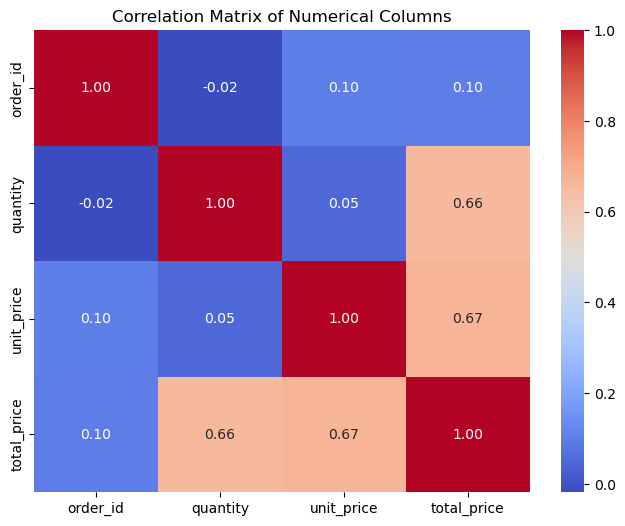

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Columns')
plt.show()

In [15]:
import sqlite3

conn = sqlite3.connect("sales_analysis.db")

df.to_sql("sales", conn, if_exists="replace", index=False)

print("Sales table created successfully.")
print("Number of rows:", len(df))

Sales table created successfully.
Number of rows: 200


In [17]:
query = """
SELECT *
FROM sales
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

display(result)

,order_id,customer_name,order_date,category,sub_category,product_name,quantity,unit_price,total_price,region
0,1000,Caleb Davis,2025-01-31 00:00:00,Clothing,Jeans,Jeans Try,2,1197,2394,West
1,1001,Misty Herrera,2025-05-05 00:00:00,Clothing,Jeans,Jeans New,9,1509,13581,South
2,1002,Rick Soto,2025-06-09 00:00:00,Clothing,Shoes,Shoes Us,5,1046,5230,East
3,1003,Sean Haas,2025-02-27 00:00:00,Furniture,Desk,Desk Section,10,292,2920,South
4,1004,Ann Hall,2025-06-01 00:00:00,Furniture,Cabinet,Cabinet Center,2,548,1096,North
5,1005,Michelle White,2025-02-07 00:00:00,Furniture,Desk,Desk Point,2,2729,5458,South
6,1006,Breanna Gonzalez,2025-04-09 00:00:00,Grocery,Bread,Bread Black,6,4356,26136,East
7,1007,Angela Rivera,2025-06-18 00:00:00,Furniture,Chair,Chair Believe,7,2971,20797,West
8,1008,Emily Anderson,2025-02-28 00:00:00,Electronics,Mobile,Mobile Evening,10,701,7010,North
9,1009,Laura Anderson,2025-02-03 00:00:00,Grocery,Snacks,Snacks Capital,1,4454,4454,East


In [18]:
query = """
SELECT *
FROM sales
WHERE category = 'Clothing';
"""

result = pd.read_sql_query(query, conn)

display(result)

,order_id,customer_name,order_date,category,sub_category,product_name,quantity,unit_price,total_price,region
0,1000,Caleb Davis,2025-01-31 00:00:00,Clothing,Jeans,Jeans Try,2,1197,2394,West
1,1001,Misty Herrera,2025-05-05 00:00:00,Clothing,Jeans,Jeans New,9,1509,13581,South
2,1002,Rick Soto,2025-06-09 00:00:00,Clothing,Shoes,Shoes Us,5,1046,5230,East
3,1015,Kylie Cox,2025-05-05 00:00:00,Clothing,Jeans,Jeans Few,3,1559,4677,East
4,1017,Tracy Williams,2025-03-14 00:00:00,Clothing,Jeans,Jeans Song,3,3222,9666,South
5,1021,Michelle Lucero,2025-04-21 00:00:00,Clothing,Shirt,Shirt Carry,2,732,1464,North
6,1022,Benjamin Meadows,2025-04-30 00:00:00,Clothing,Shoes,Shoes Job,10,2056,20560,East
7,1028,Abigail Powell,2025-05-23 00:00:00,Clothing,Shoes,Shoes Hear,1,2195,2195,West
8,1042,David Norris,2025-06-10 00:00:00,Clothing,Shoes,Shoes Far,7,3445,24115,South
9,1043,Matthew Leon,2025-01-16 00:00:00,Clothing,Jacket,Jacket Camera,1,2410,2410,South


In [19]:
query = """
SELECT
    category,
    SUM(total_price) AS total_revenue
FROM sales
GROUP BY category
ORDER BY total_revenue DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,category,total_revenue
0,Furniture,714399
1,Grocery,672147
2,Electronics,549302
3,Clothing,484259


In [20]:
query = """
SELECT
    order_id,
    customer_name,
    category,
    total_price
FROM sales
ORDER BY total_price DESC;
"""

result = pd.read_sql_query(query, conn)

display(result.head(10))

,order_id,customer_name,category,total_price
0,1125,Lynn Garrison,Grocery,47940
1,1019,Debbie Turner,Grocery,44990
2,1168,Megan Charles,Clothing,44620
3,1160,Michelle Beltran,Furniture,42471
4,1120,Rick Sanford,Furniture,41211
5,1070,Patrick Watson,Furniture,37680
6,1190,Christopher Meyer,Grocery,37320
7,1149,Todd Barnes,Furniture,36152
8,1114,Stephanie Martinez,Grocery,34576
9,1174,Kimberly Alvarado,Furniture,31752


In [21]:
query = """
SELECT
    SUM(total_price) AS total_revenue
FROM sales;
"""

result = pd.read_sql_query(query, conn)

display(result)

,total_revenue
0,2420107


In [22]:
query = """
SELECT
    AVG(total_price) AS average_order_value
FROM sales;
"""

result = pd.read_sql_query(query, conn)

display(result)

,average_order_value
0,12100.535


In [23]:
query = """
SELECT
    COUNT(*) AS total_orders
FROM sales;
"""

result = pd.read_sql_query(query, conn)

display(result)

,total_orders
0,200


In [24]:
query = """
SELECT
    customer_name,
    COUNT(*) AS number_of_orders,
    SUM(total_price) AS total_spent
FROM sales
GROUP BY customer_name
ORDER BY total_spent DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

display(result)

,customer_name,number_of_orders,total_spent
0,Lynn Garrison,1,47940
1,Debbie Turner,1,44990
2,Megan Charles,1,44620
3,Michelle Beltran,1,42471
4,Rick Sanford,1,41211
5,Patrick Watson,1,37680
6,Christopher Meyer,1,37320
7,Todd Barnes,1,36152
8,Stephanie Martinez,1,34576
9,Kimberly Alvarado,1,31752


In [25]:
query = """
SELECT
    order_id,
    customer_name,
    total_price,
    CASE
        WHEN total_price >= 10000 THEN 'High'
        WHEN total_price >= 5000 THEN 'Medium'
        ELSE 'Low'
    END AS order_category
FROM sales
ORDER BY total_price DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,order_id,customer_name,total_price,order_category
0,1125,Lynn Garrison,47940,High
1,1019,Debbie Turner,44990,High
2,1168,Megan Charles,44620,High
3,1160,Michelle Beltran,42471,High
4,1120,Rick Sanford,41211,High
...,...,...,...,...
195,1060,Rebecca Lozano,390,Low
196,1023,Nicholas Ruiz,262,Low
197,1038,Walter Pearson,253,Low
198,1108,Joshua Myers,243,Low


In [26]:
query = """
SELECT
    order_id,
    customer_name,
    category,
    total_price
FROM sales
WHERE total_price > (
    SELECT AVG(total_price)
    FROM sales
)
ORDER BY total_price DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,order_id,customer_name,category,total_price
0,1125,Lynn Garrison,Grocery,47940
1,1019,Debbie Turner,Grocery,44990
2,1168,Megan Charles,Clothing,44620
3,1160,Michelle Beltran,Furniture,42471
4,1120,Rick Sanford,Furniture,41211
...,...,...,...,...
76,1020,Roy Stewart,Electronics,13300
77,1049,Melissa Ruiz,Clothing,13300
78,1145,Sheila Booker,Electronics,12817
79,1189,Laura Smith,Clothing,12222


In [27]:
query = """
CREATE TABLE IF NOT EXISTS customers AS
SELECT
    customer_name,
    region
FROM sales
GROUP BY customer_name, region;
"""

conn.execute(query)
conn.commit()

print("Customers table created.")

Customers table created.


In [28]:
query = """
SELECT
    s.order_id,
    s.customer_name,
    c.region,
    s.category,
    s.total_price
FROM sales AS s
JOIN customers AS c
    ON s.customer_name = c.customer_name
ORDER BY s.total_price DESC;
"""

result = pd.read_sql_query(query, conn)

display(result.head(10))

,order_id,customer_name,region,category,total_price
0,1125,Lynn Garrison,East,Grocery,47940
1,1019,Debbie Turner,West,Grocery,44990
2,1168,Megan Charles,West,Clothing,44620
3,1160,Michelle Beltran,East,Furniture,42471
4,1120,Rick Sanford,South,Furniture,41211
5,1070,Patrick Watson,West,Furniture,37680
6,1190,Christopher Meyer,East,Grocery,37320
7,1149,Todd Barnes,North,Furniture,36152
8,1114,Stephanie Martinez,West,Grocery,34576
9,1174,Kimberly Alvarado,North,Furniture,31752


In [29]:
query = """
SELECT
    category,
    COUNT(*) AS total_orders,
    SUM(quantity) AS total_quantity,
    SUM(total_price) AS total_revenue,
    AVG(total_price) AS average_order_value
FROM sales
GROUP BY category
ORDER BY total_revenue DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,category,total_orders,total_quantity,total_revenue,average_order_value
0,Furniture,59,269,714399,12108.457627
1,Grocery,49,269,672147,13717.285714
2,Electronics,52,217,549302,10563.500000
3,Clothing,40,227,484259,12106.475000
